In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify as sq

aisles = pd.read_csv('./aisles.csv')
departments = pd.read_csv('./departments.csv')
products = pd.read_csv('./products.csv')
orders = pd.read_csv('./orders.csv')
order_products = pd.read_csv('./order_products.csv') 

aisles = aisles.dropna(subset=['aisle_id' , 'aisle'])
departments = departments.dropna(subset=['department_id' , 'department'])
order_products = order_products.dropna(subset=['order_id','product_id'])
orders = orders.dropna(subset=["order_id","user_id","order_dow"])
products = products.dropna(subset=['product_id','product_name'])

products_enriched = products.merge(aisles, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments, on='department_id', how='left')
orders_details = order_products.merge(orders, on='order_id', how='left')
df_master = orders_details.merge(products_enriched, on='product_id', how='left')

##  Peak hour of orders 

 je dois prendre les heures de toutes les commandes et trouver l'heure avec le plus de commandes

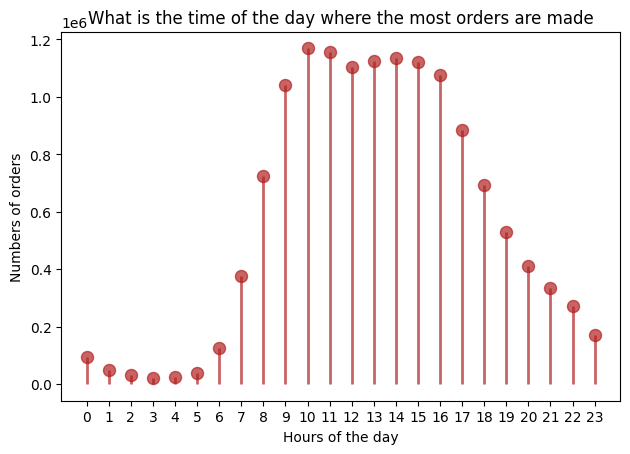

In [5]:
df_hours = (df_master["order_hour_of_day"].dropna().astype(int).value_counts().sort_index())
fig, ax = plt.subplots()
ax.set_title('What is the time of the day where the most orders are made')
ax.vlines(x=df_hours.index, ymin=0, ymax=df_hours , color='firebrick', alpha=0.7, linewidth=2)
ax.scatter(x=df_hours.index, y=df_hours, s=75, color='firebrick', alpha=0.7)
ax.set_xticks(df_hours.index)
ax.set_xlabel('Hours of the day')
ax.set_ylabel('Numbers of orders')
plt.tight_layout()

## Which item do customers put in their cart first?

pour faire ca je dois recuperer le premier produit (product_id) de chaque order (add_to_cart_order) 

product_name
Banana                    46966
Bag of Organic Bananas    33425
Organic Whole Milk        13119
Organic Strawberries      11674
Organic Hass Avocado      10210
Name: count, dtype: int64

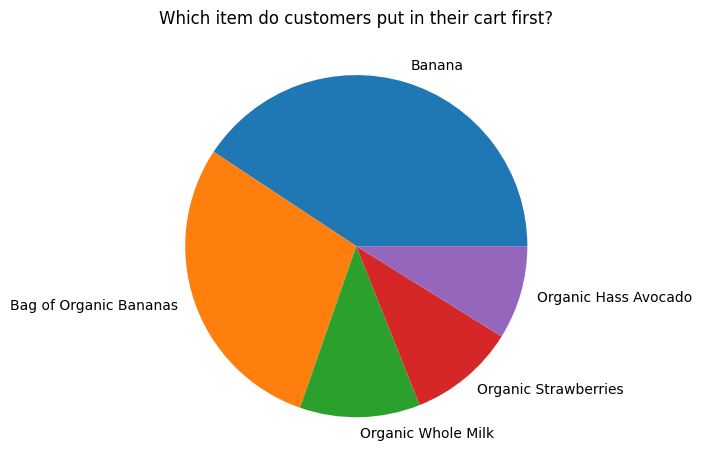

In [6]:
dfpipi = df_master[df_master['add_to_cart_order'] == 1 ]['product_name'].dropna().value_counts().head(5)
display(dfpipi)

fig, ax = plt.subplots()
ax.pie(dfpipi, labels=dfpipi.index)
ax.set_title('Which item do customers put in their cart first?')
plt.tight_layout()

## What is the average size of a cart 

je dois recuperer le nombre produits dans chaque order et faire une moyenne du nombre de produit 

np.float64(10.08621999073323)

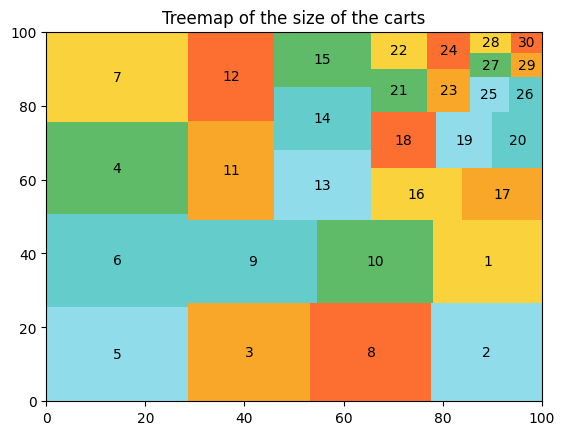

In [23]:
df_ave = df_master['order_id'].value_counts().value_counts().head(30)
df_avemean = df_master['order_id'].value_counts().mean()
fig, ax = plt.subplots()
sq.plot(df_ave,label=df_ave.index,color = ['#91DCEA', '#64CDCC', '#5FBB68', '#F9D23C', '#F9A729', '#FD6F30'])
plt.title('Treemap of the size of the carts')
display(df_avemean)